In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e10/sample_submission.csv
/kaggle/input/playground-series-s4e10/train.csv
/kaggle/input/playground-series-s4e10/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

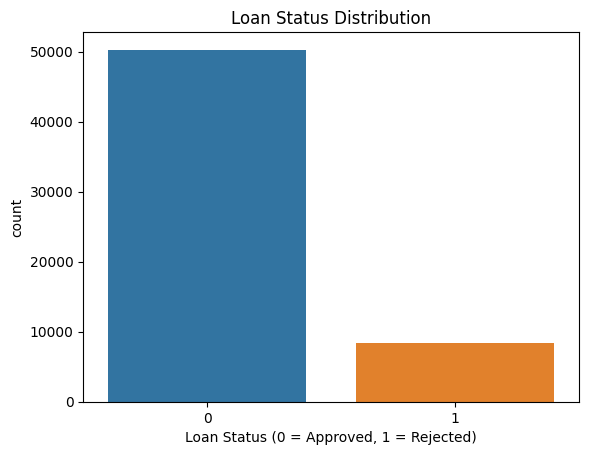

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


In [4]:
# Target distribution
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = Approved, 1 = Rejected)")
plt.show()

# Class balance
print(df['loan_status'].value_counts(normalize=True))

In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [6]:
categorical = df.select_dtypes(include='object').columns.tolist()
numerical = df.select_dtypes(include=['int64', 'float64']).drop(['loan_status', 'id'], axis=1).columns.tolist()
print("Categorical:", categorical)
print("Numerical:", numerical)

Categorical: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numerical: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


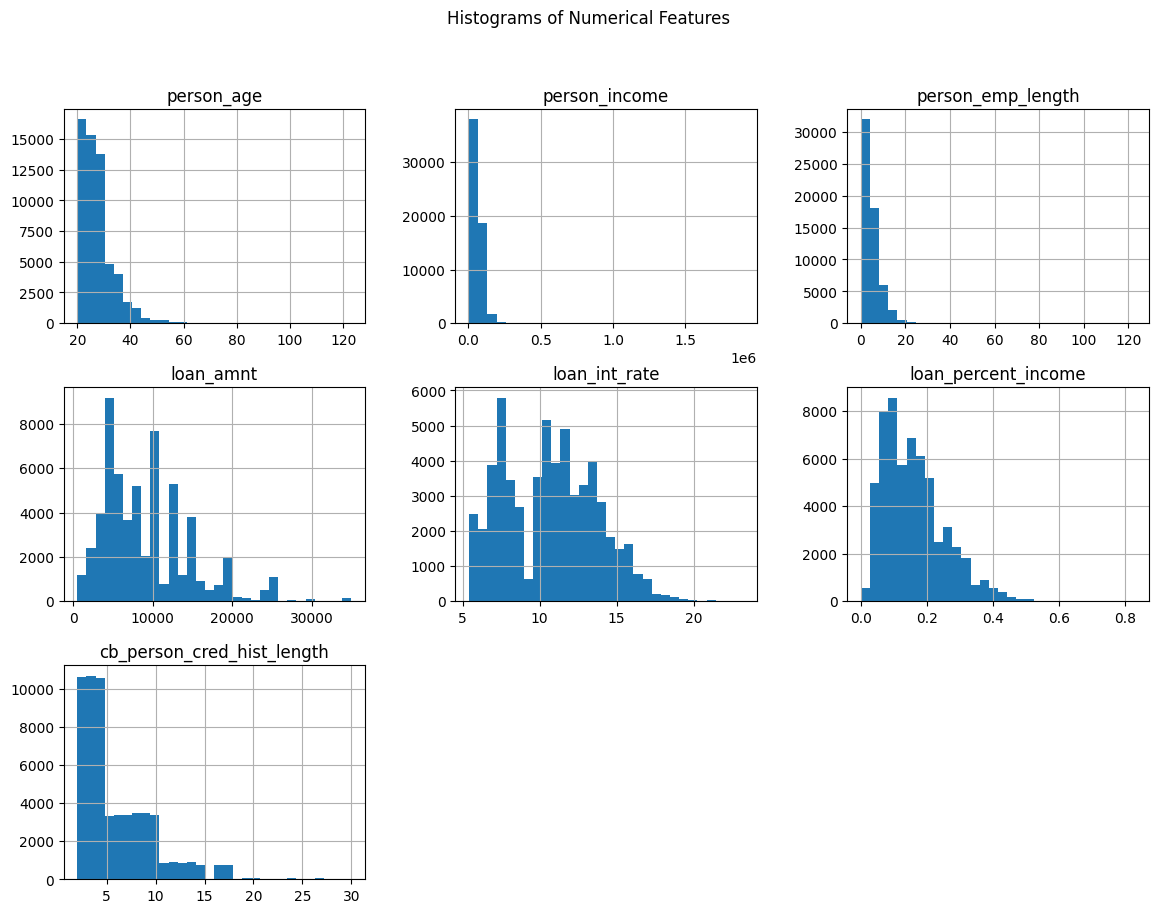

In [7]:
df[numerical].describe()
df[numerical].hist(bins=30, figsize=(14, 10))
plt.suptitle("Histograms of Numerical Features")
plt.show()

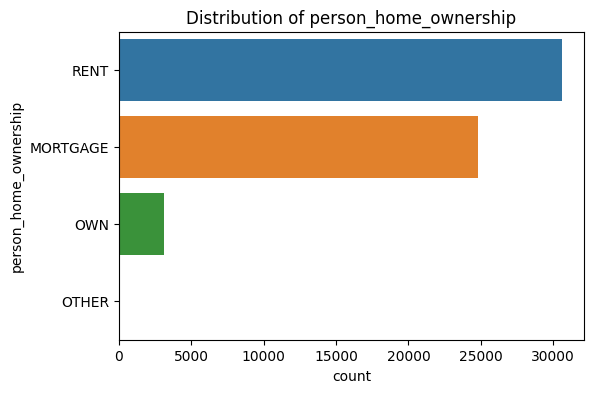

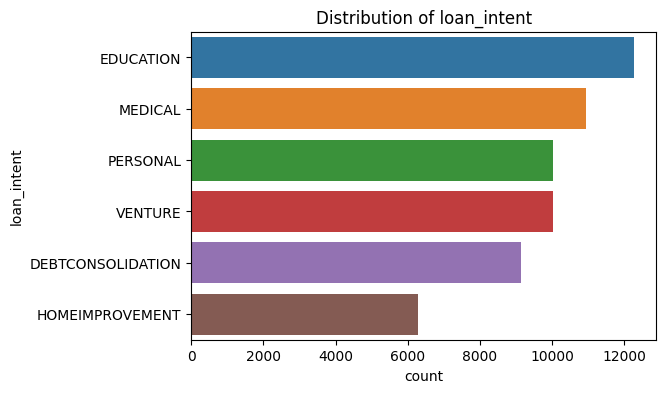

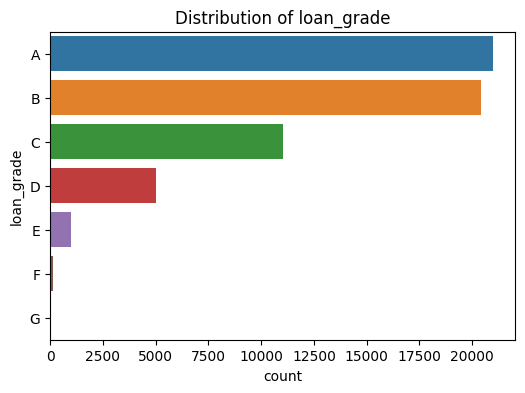

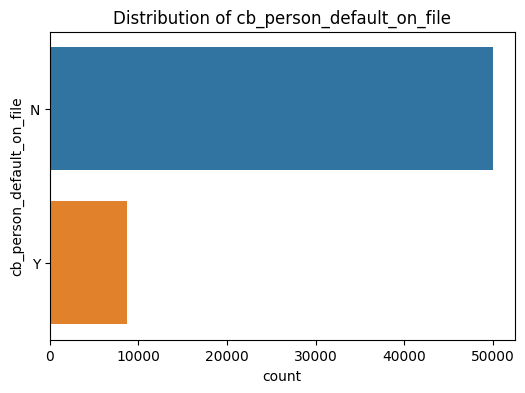

In [8]:
for col in categorical:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

loan_percent_income           0.378280
loan_int_rate                 0.338948
person_income                -0.169956
loan_amnt                     0.144982
person_emp_length            -0.100428
cb_person_cred_hist_length   -0.003030
person_age                   -0.001130
dtype: float64


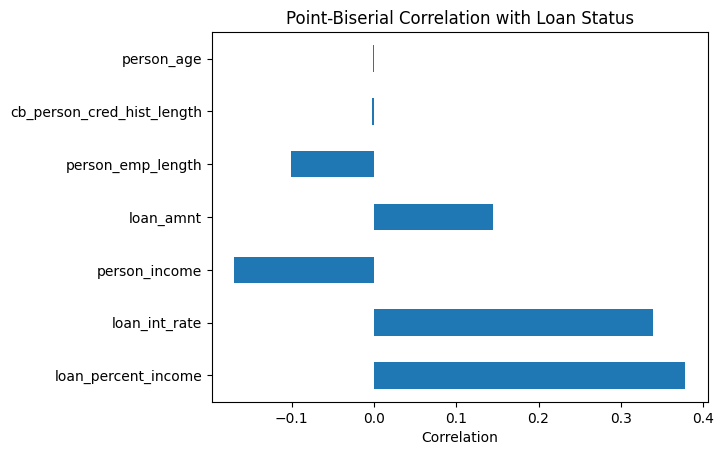

In [9]:
import numpy as np
from scipy.stats import pointbiserialr

corrs = {}
for col in numerical:
    corr, _ = pointbiserialr(df[col], df['loan_status'])
    corrs[col] = corr

corr_df = pd.Series(corrs).sort_values(key=abs, ascending=False)
print(corr_df)

# Plot
corr_df.plot(kind='barh', title="Point-Biserial Correlation with Loan Status")
plt.xlabel("Correlation")
plt.show()

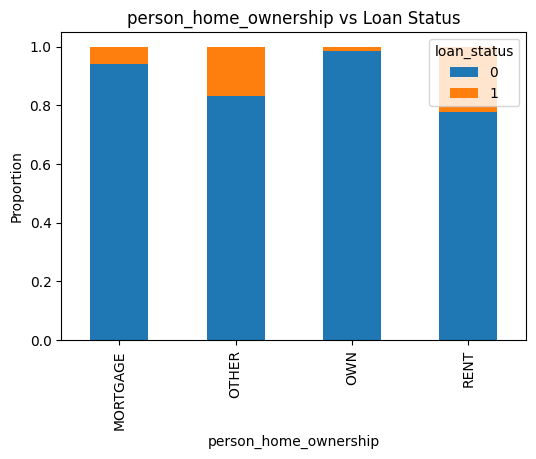

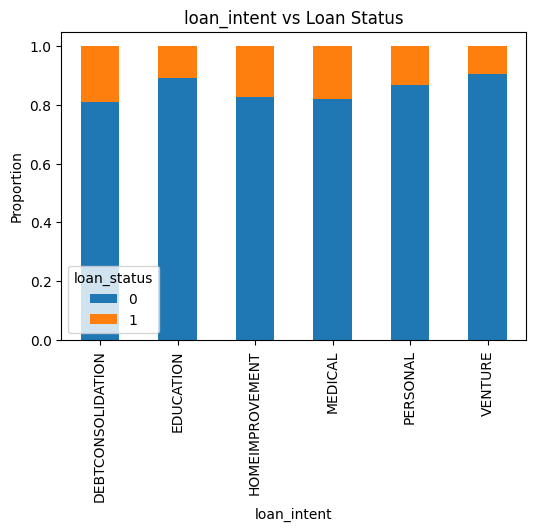

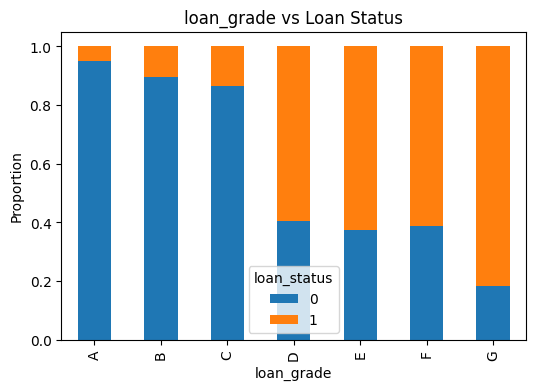

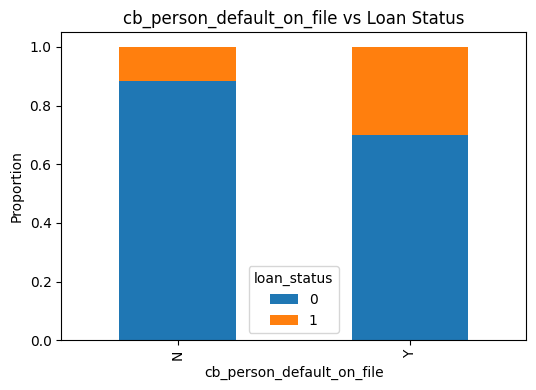

In [10]:
for col in categorical:
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index')
    ct.plot(kind='bar', stacked=True, title=f"{col} vs Loan Status", figsize=(6,4))
    plt.ylabel("Proportion")
    plt.show()

In [11]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='person_income',
    y='loan_amnt',
    z='loan_status',
    color='loan_status',
    title='Interactive 3D Scatter Plot: Income vs Loan Amount vs Age',
    opacity=0.8
)

fig.update_layout(
    scene=dict(
        zaxis=dict(range=[0, 5])  # Compresses Z-axis
    )
)

# Show the figure
fig.show()

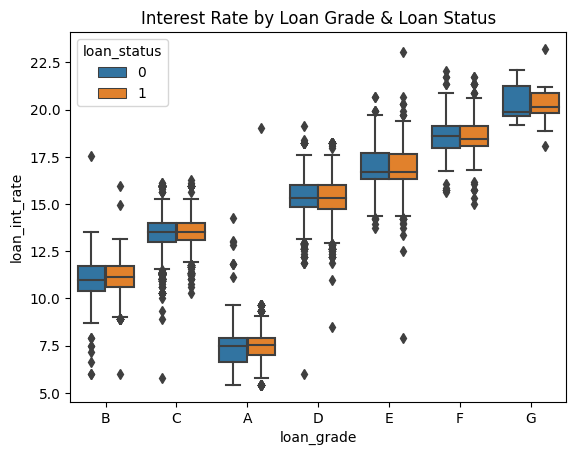

In [12]:
sns.boxplot(x='loan_grade', y='loan_int_rate', hue='loan_status', data=df)
plt.title("Interest Rate by Loan Grade & Loan Status")
plt.show()

In [13]:
from scipy.stats import zscore
z_scores = df[numerical].apply(zscore)
outliers = (z_scores.abs() > 3).sum()
print("Number of outliers per feature:\n", outliers)

Number of outliers per feature:
 person_age                    1010
person_income                  533
person_emp_length              627
loan_amnt                      345
loan_int_rate                   66
loan_percent_income            459
cb_person_cred_hist_length     492
dtype: int64


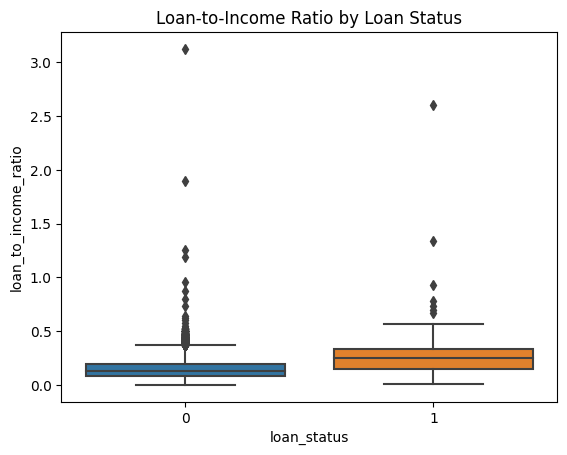

In [14]:
df['loan_to_income_ratio'] = df['loan_amnt'] / (df['person_income'] + 1)
sns.boxplot(x='loan_status', y='loan_to_income_ratio', data=df)
plt.title("Loan-to-Income Ratio by Loan Status")
plt.show()

In [15]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

In [16]:
!pip install scikit-learn==1.3.0 imbalanced-learn==0.11.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.0 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.3.0 which is incompatible.


# XGB

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
# from sklearn.over_sampling import SMOTE
# from imblearn.over_sampling import RandomOverSampler

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [18]:
# # Create pipeline
# model_pipeline = Pipeline(steps=[
#     ('preprocess', preprocessor),
#     # ('smote', SMOTE(random_state=42)),
#     ('classifier', XGBClassifier(
#         random_state=42,
#         scale_pos_weight=6,  # Because class imbalance ~ 86:14
#         use_label_encoder=False,
#         eval_metric='logloss'
#     ))
# ])

# # Train the model
# model_pipeline.fit(X_train, y_train)

In [19]:
# # Predictions
# y_pred = model_pipeline.predict(X_test)
# y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# # Metrics
# print("Classification Report:\n", classification_report(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("AUC Score:", roc_auc_score(y_test, y_proba))

# Neural Network

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-05-01 10:39:33.164487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746095973.442503      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746095973.533257      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [21]:
# 2) Separate label
y = df["loan_status"]
X = df.drop(columns=["loan_status", "id"], errors="ignore")

# 3) Feature Engineering
def add_features(df):
    df = df.copy()
    # Loan‑to‑Income ratio
    df["loan_to_income"] = df["loan_amnt"] / (df["person_income"] + 1)
    # Employment length buckets
    df["emp_length_bin"] = pd.cut(
        df["person_emp_length"],
        bins=[-1, 0, 2, 5, 10, np.inf],
        labels=["<0yr","0–2yr","2–5yr","5–10yr","10+yr"]
    )
    return df

featurizer = FunctionTransformer(add_features)

# 4) Column lists after engineering
numeric_feats = [
    "person_age", "person_income", "loan_amnt",
    "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "loan_to_income"
]
ordinal_feats = ["loan_grade"]      # assume A,B,C… maps to order
ordinal_mapping = [["A","B","C","D","E","F","G"]]
categorical_feats = [
    "person_home_ownership", "loan_intent",
    "cb_person_default_on_file", "emp_length_bin"
]

# 5) Preprocessing pipelines
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

ord_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="A")),
    ("encode", OrdinalEncoder(categories=ordinal_mapping))
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
])

preprocessor = ColumnTransformer([
    ("num",  num_pipeline, numeric_feats),
    ("ord",  ord_pipeline, ordinal_feats),
    ("cat",  cat_pipeline, categorical_feats),
])

In [22]:
# 6) Create full pipeline
full_pipeline = Pipeline([
    ("feature_engineering", featurizer),
    ("preprocessing", preprocessor)
])

# 7) Preprocess the data
X_processed = full_pipeline.fit_transform(X)

# 8) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



In [23]:
# 9) Convert to TensorFlow format
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

2025-05-01 10:39:48.327877: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')  # Output for binary classification
# ])

# model.compile(
#     optimizer='adam',
#     loss='binary_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
# )

# # 11) Add early stopping
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # 12) Train the model
# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=1
# )

In [25]:
# # 13) Evaluate
# y_pred_prob = model.predict(X_test).flatten()
# y_pred = (y_pred_prob >= 0.5).astype(int)

# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
# print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

In [26]:
# test = pd.read_csv('/kaggle/input/playground-series-s4e10/test.csv')
# test

In [27]:
# test['loan_to_income_ratio'] = test['loan_amnt'] / (test['person_income'] + 1)

In [28]:
# test_processed = full_pipeline.fit_transform(test)

In [29]:
# output = model.predict(test_processed).flatten()

In [30]:
# output

In [31]:
# result = pd.DataFrame({
#     'id': test['id'],
#     'loan_status': output
# })
# result

In [32]:
# output = model_pipeline.predict(test)
# output

In [33]:
# result = pd.DataFrame({
#     'id': test['id'],
#     'loan_status': output
# })
# result

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import tensorflow as tf
import numpy as np
from tensorflow.keras.optimizers import Adam

In [35]:
# X_processed

In [36]:
# units_input: 256
# bn_input: False
# act_input: relu
# dropout_input: 0.2
# num_layers: 3
# units_0: 32
# bn_0: False
# dropout_0: 0.30000000000000004
# lr: 0.005118522483814269
# units_1: 256
# bn_1: False
# dropout_1: 0.30000000000000004
# units_2: 128
# bn_2: True
# dropout_2: 0.4


n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

auc_scores = []
oof_preds = np.zeros(len(X))  # Same length as original data
models= []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y)):
    print(f"\n--- Fold {fold+1} ---")
    
    X_train_fold, X_val_fold = X_processed[train_idx], X_processed[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    optimizer = Adam(learning_rate=0.005118522483814269)

    # Define model inside loop to reset weights each fold
    model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_processed.shape[1],)),  # 👈 clean way to declare input shape
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(X_train_fold, y_train_fold,
              validation_data=(X_val_fold, y_val_fold),
              epochs=50,
              batch_size=32,
              callbacks=[early_stop],
              verbose=1)
    
    # Predictions
    val_preds = model.predict(X_val_fold).ravel()
    oof_preds[val_idx] = val_preds
    auc = roc_auc_score(y_val_fold, val_preds)
    auc_scores.append(auc)
    models.append((model, auc))
    models_sorted = sorted(models, key=lambda x: x[1], reverse=True)
    print(f"Fold {fold+1} AUC: {auc:.4f}")

best_model, best_auc = models_sorted[0]
print(f"Best AUC: {best_auc:.4f}")


--- Fold 1 ---
Epoch 1/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8864 - auc: 0.8622 - loss: 0.2908 - val_accuracy: 0.9294 - val_auc: 0.9173 - val_loss: 0.2176
Epoch 2/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9281 - auc: 0.9073 - loss: 0.2203 - val_accuracy: 0.9364 - val_auc: 0.9191 - val_loss: 0.2002
Epoch 3/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9357 - auc: 0.9149 - loss: 0.2033 - val_accuracy: 0.9448 - val_auc: 0.9206 - val_loss: 0.1934
Epoch 4/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9385 - auc: 0.9156 - loss: 0.2009 - val_accuracy: 0.9444 - val_auc: 0.9242 - val_loss: 0.1893
Epoch 5/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9383 - auc: 0.9162 - loss: 0.2003 - val_accuracy: 0.9454 - val_auc: 0.9223 - val_loss: 0.1891
Epoch 6/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9404 - auc: 0.9166 - loss: 0.1967 - val_accuracy: 0.9429 - val_auc: 0.9215 - val_loss: 0.1962
Epoch 7/50


In [37]:
# test = models[6]
# model = test[0]

In [38]:
# output = model.predict(test_processed).flatten()
# output

In [39]:
# result = pd.DataFrame({
#     'id': test['id'],
#     'loan_status': output
# })
# result

In [40]:
# result.to_csv('submission.csv', index=False)

# Hyperparameter Tuning

In [41]:
# import keras_tuner as kt
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
# from tensorflow.keras.optimizers import Adam, RMSprop

# def build_model(hp):
#     model = Sequential()
    
#     # First Dense Layer
#     model.add(Dense(
#         units=hp.Choice('units_input', [32, 64, 128, 256]),
#         input_shape=(X_train.shape[1],)
#     ))
#     if hp.Boolean('bn_input'):
#         model.add(BatchNormalization())
#     model.add(Activation(hp.Choice('act_input', ['relu', 'tanh'])))
#     model.add(Dropout(hp.Float('dropout_input', 0.2, 0.5, step=0.1)))

#     # Hidden Layers
#     for i in range(hp.Int('num_layers', 1, 3)):
#         model.add(Dense(
#             units=hp.Choice(f'units_{i}', [32, 64, 128, 256])
#         ))
#         if hp.Boolean(f'bn_{i}'):
#             model.add(BatchNormalization())
#         model.add(Activation('relu'))
#         model.add(Dropout(hp.Float(f'dropout_{i}', 0.2, 0.5, step=0.1)))

#     # Output Layer
#     model.add(Dense(1, activation='sigmoid'))

#     # Optimizer
#     learning_rate = hp.Float('lr', 1e-4, 1e-2, sampling='log')
#     optimizer = Adam(learning_rate=learning_rate)

#     model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
#     return model

In [42]:
# tuner = kt.RandomSearch(
#     build_model,
#     objective='val_accuracy',
#     max_trials=30,
#     executions_per_trial=2,
#     directory='my_dir',
#     project_name='tune_with_bn'
# )

# # tuner.search(X_processed, y, epochs=20, validation_split=0.2)

In [43]:
# # Get the best hyperparameter configuration
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# # Print each hyperparameter value
# for param in best_hps.values:
#     print(f"{param}: {best_hps.get(param)}")